In [1]:
# Load env variables and create client
import os
from pathlib import Path

from anthropic import Anthropic
from dotenv import load_dotenv

load_dotenv(override=True)

client = Anthropic(
    base_url="https://openrouter.ai/api",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

model = (
    "claude-sonnet-4-5-20250929"  # "deepseek/deepseek-v4.1-flash" # "claude-sonnet-4-5-20250929"
)

In [2]:
# Helper functions
from anthropic.types import Message


def add_user_message(messages, message):
    user_message = {
        "role": "user",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(assistant_message)


def chat(
    messages,
    system=None,
    temperature=1.0,
    stop_sequences=[],
    tools=None,
    thinking=False,
    thinking_budget=2000,
):
    params = {
        "model": model,
        "max_tokens": 10000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if thinking:
        params["thinking"] = {
            "type": "enabled",
            "budget_tokens": thinking_budget,
        }

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message


def text_from_message(message):
    return "\n".join([block.text for block in message.content if block.type == "text"])


def upload(file_path):
    path = Path(file_path)
    extension = path.suffix.lower()

    mime_type_map = {
        ".pdf": "application/pdf",
        ".txt": "text/plain",
        ".md": "text/plain",
        ".py": "text/plain",
        ".js": "text/plain",
        ".html": "text/plain",
        ".css": "text/plain",
        ".csv": "text/csv",
        ".json": "application/json",
        ".xml": "application/xml",
        ".xlsx": "application/vnd.openxmlformats-officedocument.spreadsheetml.sheet",
        ".xls": "application/vnd.ms-excel",
        ".jpeg": "image/jpeg",
        ".jpg": "image/jpeg",
        ".png": "image/png",
        ".gif": "image/gif",
        ".webp": "image/webp",
    }

    mime_type = mime_type_map.get(extension)

    if not mime_type:
        raise ValueError(f"Unknown mimetype for extension: {extension}")
    filename = path.name

    with open(file_path, "rb") as file:
        return client.beta.files.upload(file=(filename, file, mime_type))


def list_files():
    return client.beta.files.list()


def delete_file(id):
    return client.beta.files.delete(id)


def get_metadata(id):
    return client.beta.files.retrieve_metadata(id)


# OpenRouter sandbox. The SDK doesn't know openrouter_shell_tool_result blocks and parses
# them loosely, so container_id is present on some of them only - take the first one that has it.
def container_id(message):
    for b in message.content:
        if b.type == "openrouter_shell_tool_result" and getattr(b, "container_id", None):
            return b.container_id
    raise ValueError("No sandbox container in this response - the model never ran a command")


def list_container_files(cid):
    files = client.get(f"/v1/containers/{cid}/files", cast_to=object)["data"]
    return [f for f in files if not f["path"].endswith("/")]


def download_container_file(cid, file, dest="."):
    # The SDK's typed get() can't return raw bytes, so use its underlying HTTP client
    response = client._client.get(
        f"{client.base_url}v1/containers/{cid}/files/{file['id']}/content",
        headers={"Authorization": f"Bearer {client.api_key}"},
    )
    response.raise_for_status()
    out = Path(dest) / Path(file["path"]).name
    out.write_bytes(response.content)
    return out

In [3]:
file_metadata = upload("streaming.csv")
file_metadata

FileMetadata(id='or_file_0VWo7WZjBnYXZ1eGEfc58k5L', created_at=datetime.datetime(2026, 10, 1, 14, 16, 4, 925000, tzinfo=datetime.timezone.utc), filename='streaming.csv', mime_type='text/csv', size_bytes=25733, type='file', downloadable=False, scope=None, _shape='anthropic')

In [4]:
messages = []

# OpenRouter mounts each file_id into the sandbox home dir as ~/<last 8 chars of id>-<filename>
csv_path = f"~/{file_metadata.id[-8:]}-{file_metadata.filename}"

add_user_message(
    messages,
    f"""
Run a detailed analysis of {csv_path} to determine major drivers of churn.
Your final output should include at least one detailed plot summarizing your findings.
Save every plot as a PNG file in the home directory.
""",
)

shell_tool = {
    "type": "openrouter:shell",
    "parameters": {
        "engine": "openrouter",
        "environment": {"type": "container_auto", "file_ids": [file_metadata.id]},
    },
}

response = chat(messages, tools=[shell_tool])
print(text_from_message(response))

I'll analyze the streaming data to determine major drivers of churn. Let me start by exploring the dataset.
Good! Now let me perform a comprehensive analysis using Python to understand the churn drivers.
Great! Now let me perform detailed churn analysis:
Excellent! Now let me create correlation analysis and identify the strongest predictors:
Perfect! Now let me create comprehensive visualizations:
Excellent! Now let me create an additional detailed summary visualization focusing on the top churn drivers:
Perfect! Now let me create a final comprehensive summary report with all the key findings:
Perfect! Now let me verify the files were created and provide a final summary:
Excellent! Let me create one final detailed visualization showing the risk segmentation:
Perfect! Now let me create a final summary document:
Perfect! Let me verify all files one more time:
## 🎯 Analysis Complete!

I've conducted a comprehensive churn analysis of the streaming service data (~/Efc58k5L-streaming.csv) an

containers: {'gen_7a32f6b8420e'}
gen_7a32f6b8420e ['.cache/matplotlib/fontlist-v3.11.0.json', 'Efc58k5L-streaming.csv', 'churn_analysis_comprehensive.png', 'churn_drivers_summary.png', 'risk_segmentation_analysis.png']


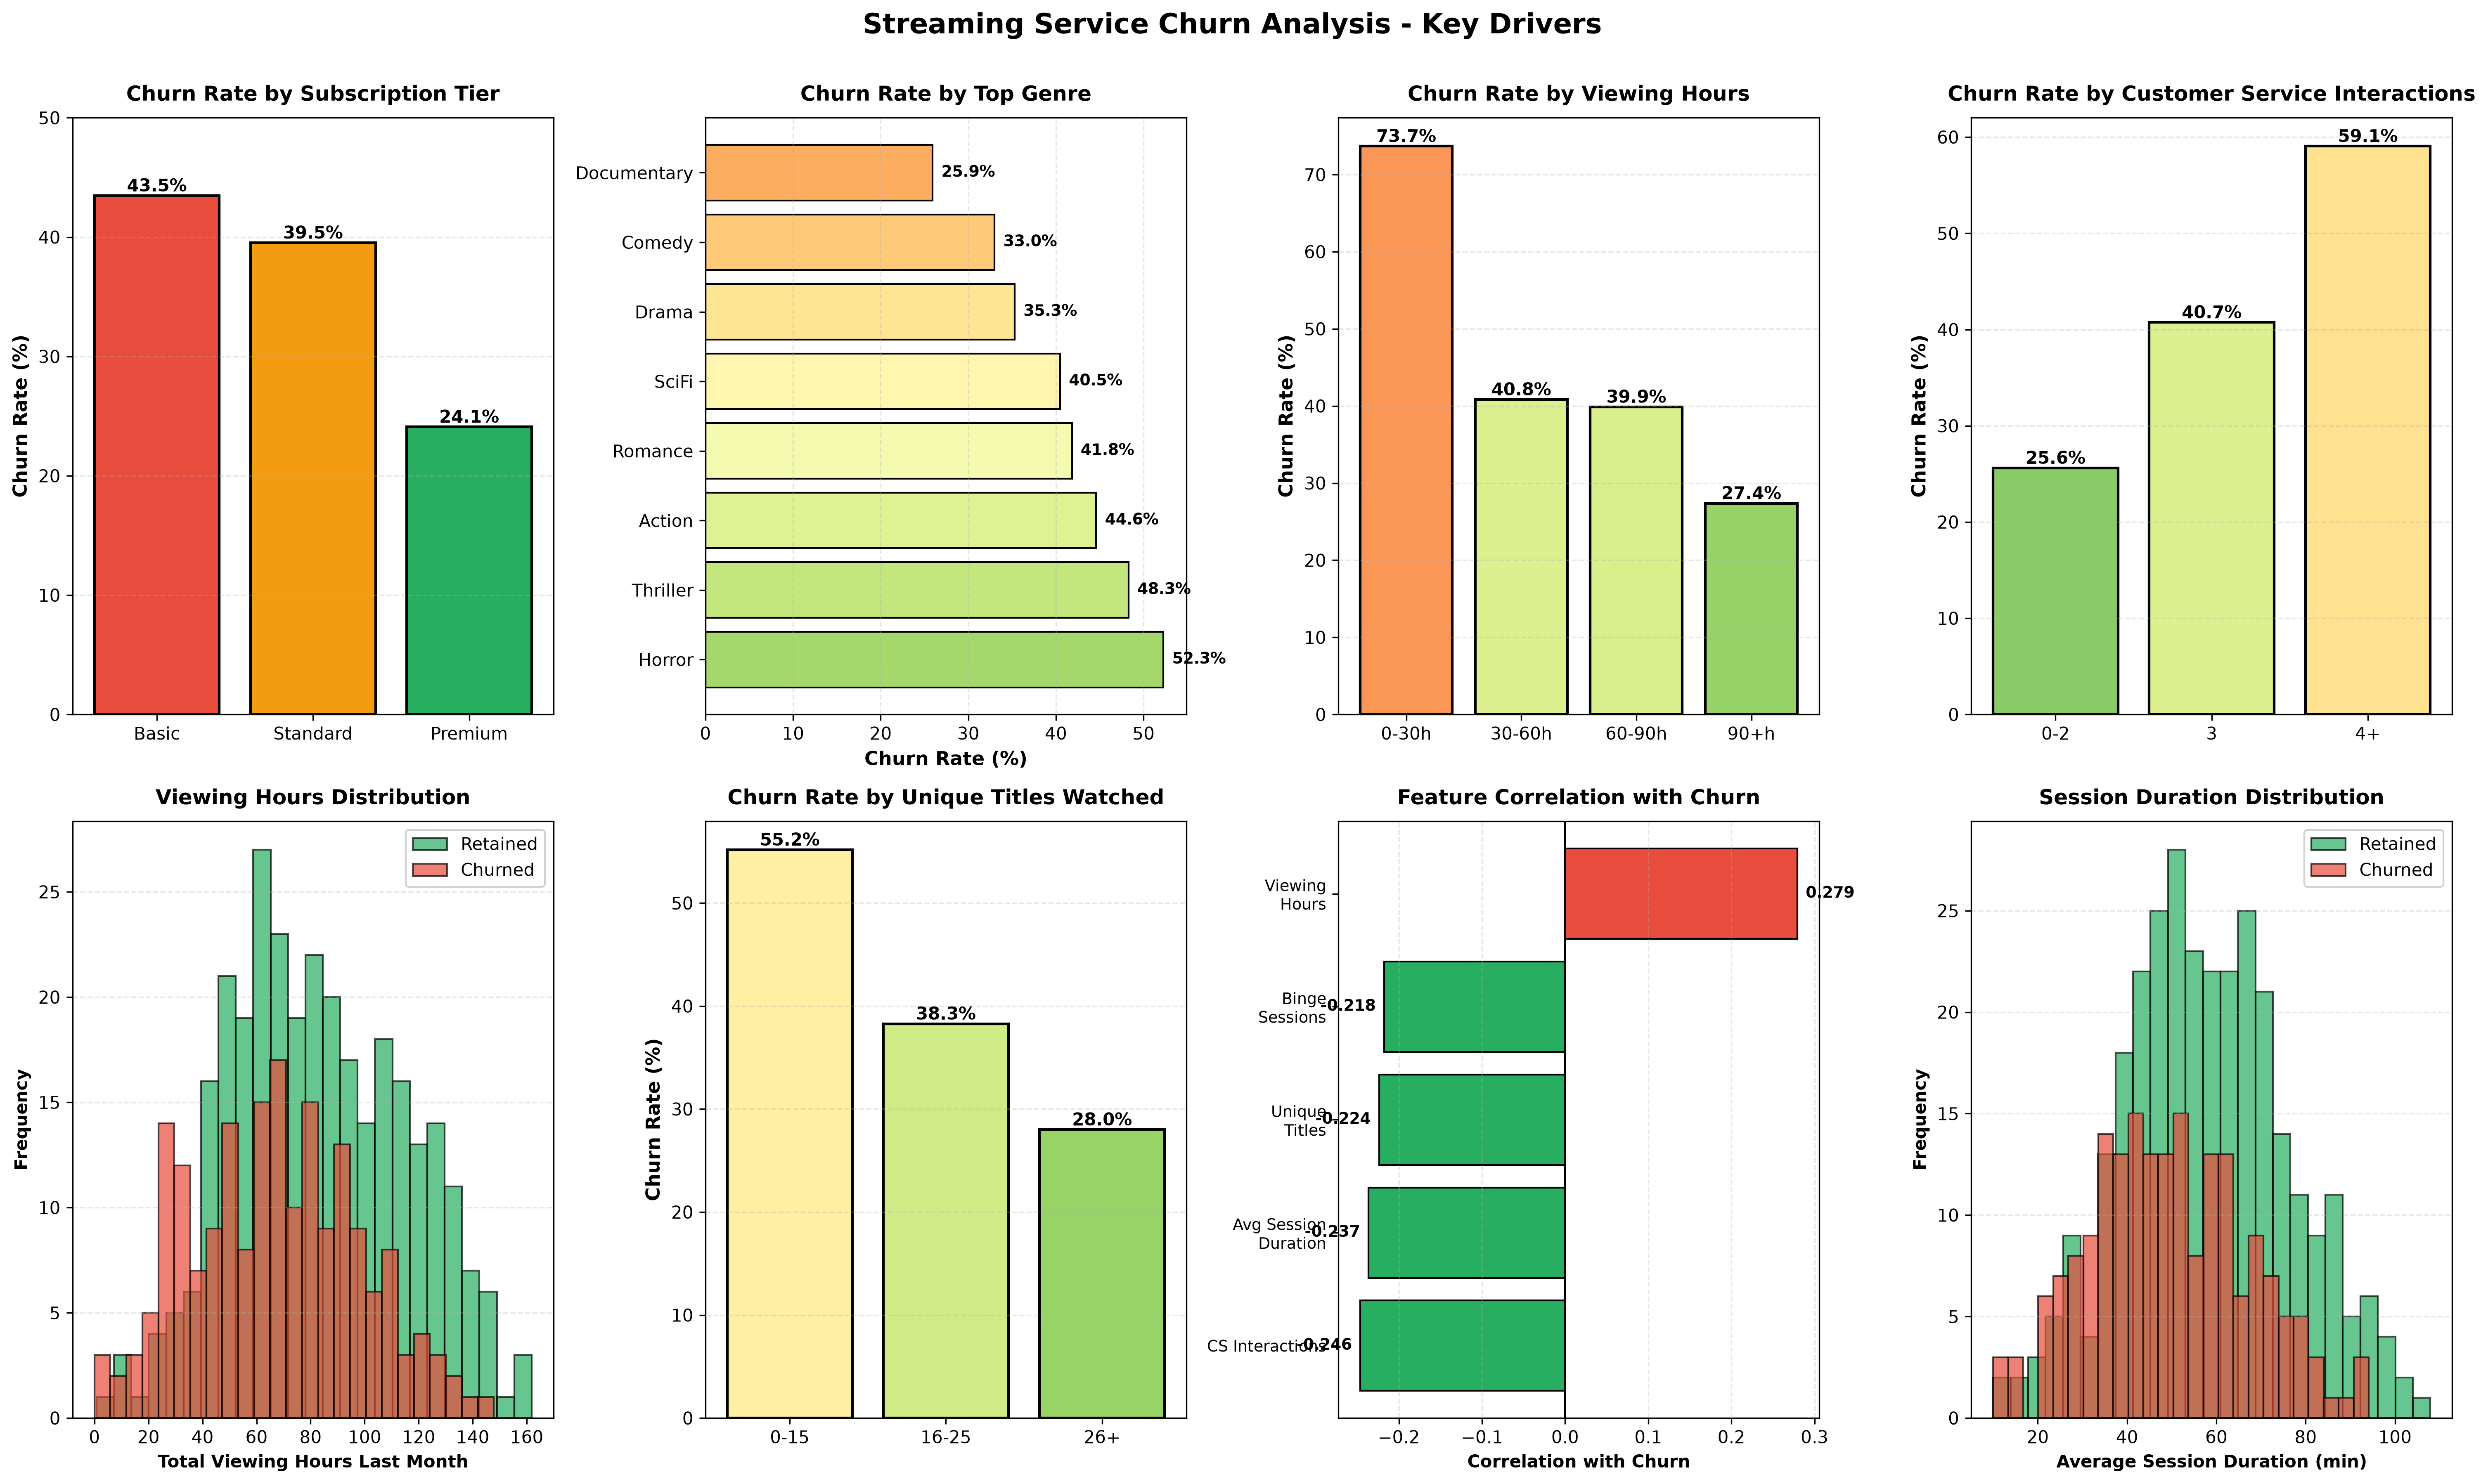

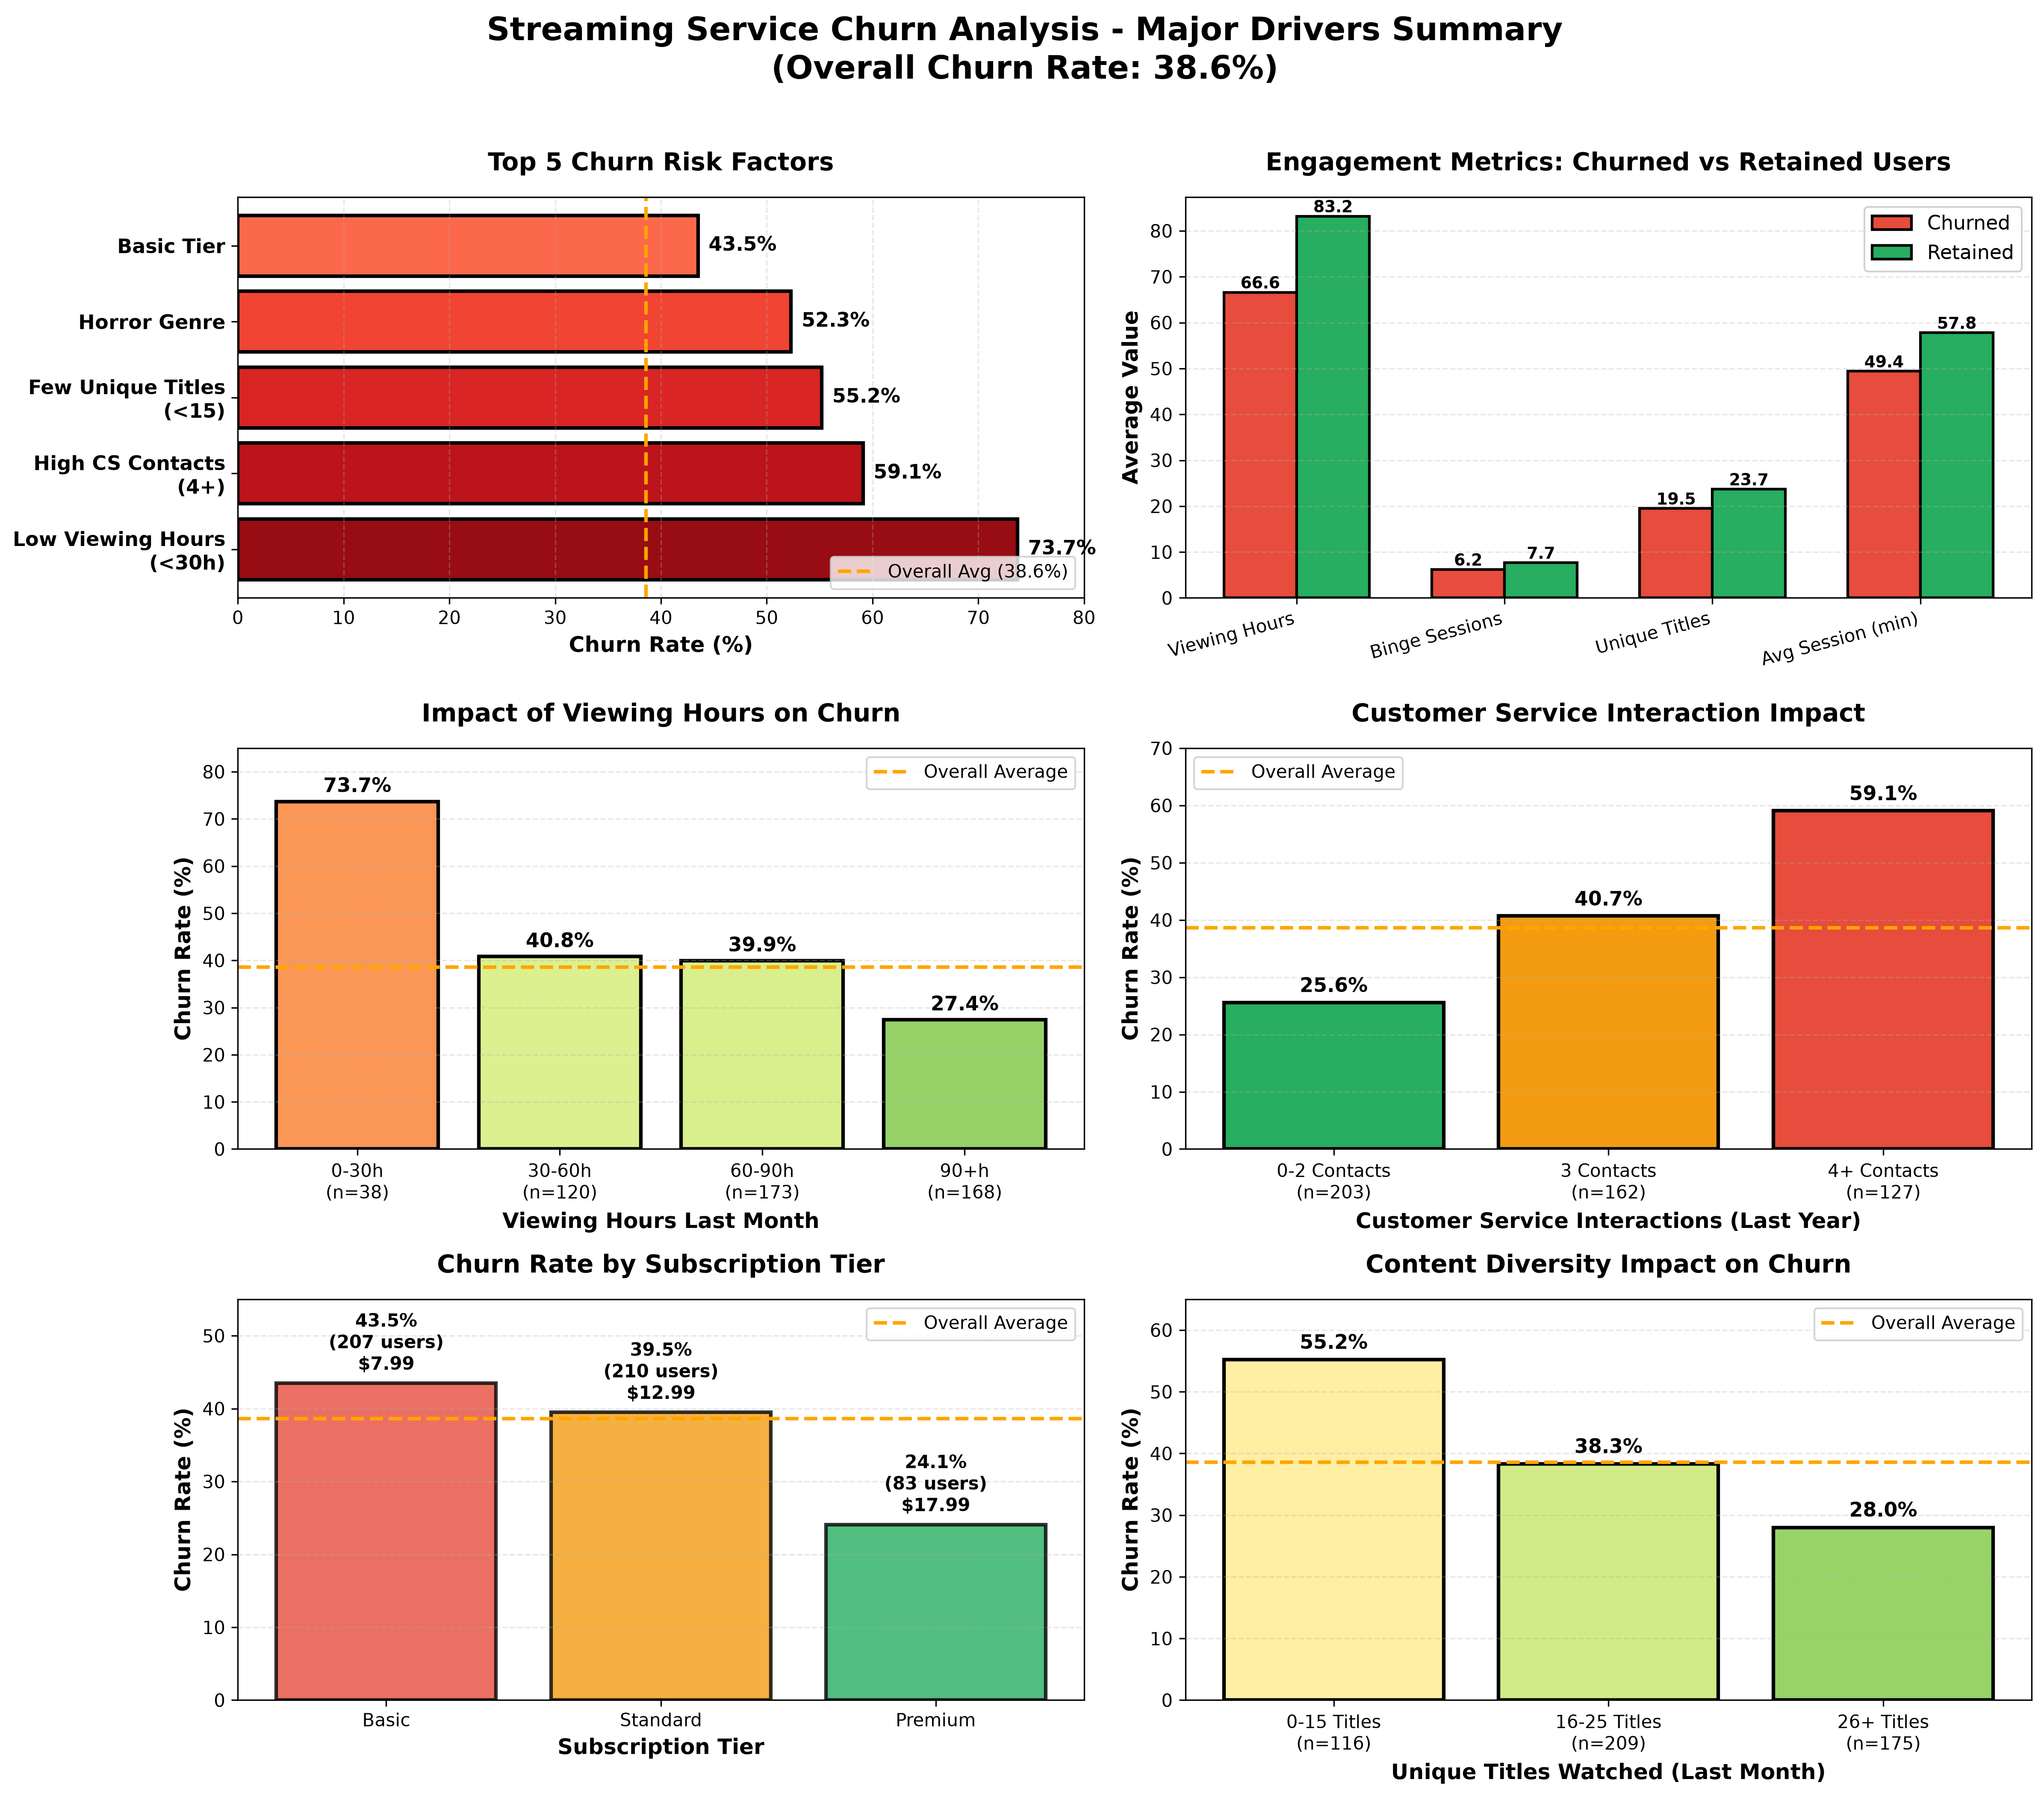

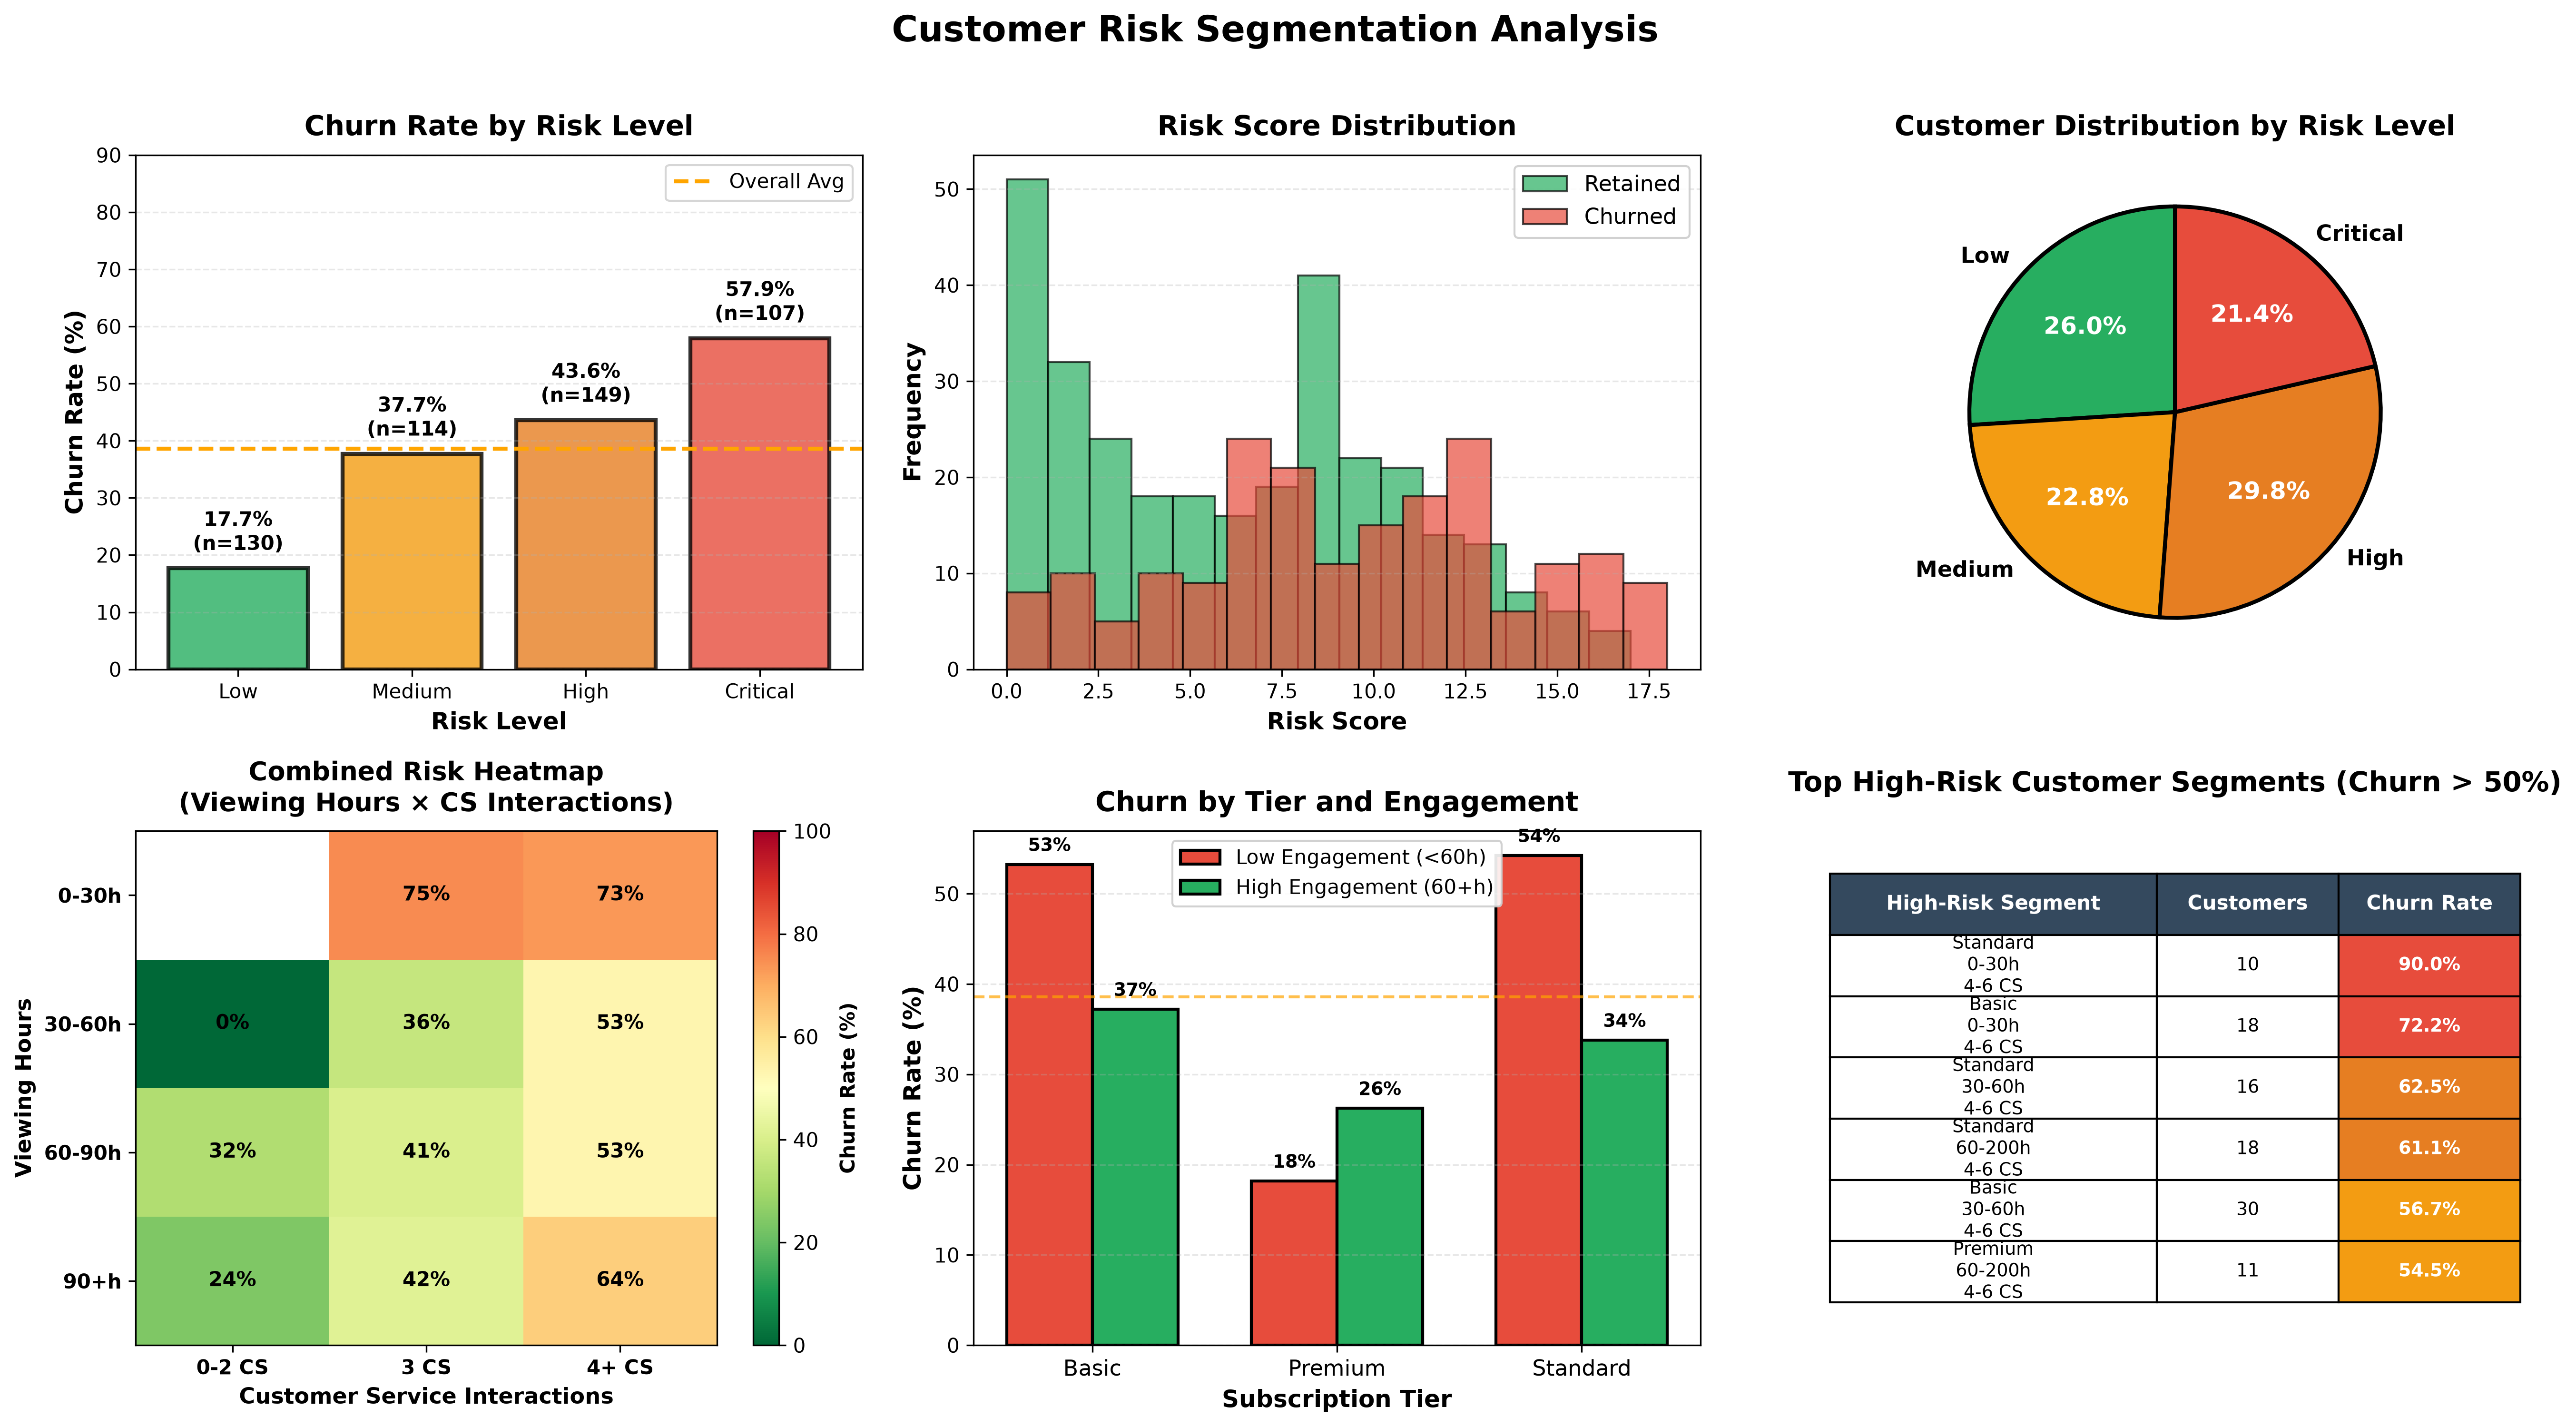

In [5]:
from IPython.display import Image, display

# A long run can span several sandbox containers, so check every one the response mentions
cids = {
    b.container_id
    for b in response.content
    if b.type == "openrouter_shell_tool_result" and getattr(b, "container_id", None)
}
print("containers:", cids)

for cid in cids:
    files = list_container_files(cid)
    print(cid, [f["path"] for f in files])
    for file in files:
        if file["path"].endswith(".png"):
            display(Image(filename=download_container_file(cid, file)))